# **Importing and exploring the data**

In [53]:
# Data manipulation and Numerical computing
import pandas as pd  
import numpy as np  

# plots and visualisations
import matplotlib.pyplot as plt 
import seaborn as sns 

In [54]:
df = pd.read_csv('email.csv', encoding='latin-1')

In [55]:
print("Dataset Shape:", df.shape)

Dataset Shape: (5573, 2)


In [56]:
print("\nFirst 5 entries:")
print(df.head())


First 5 entries:
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [57]:
print("\nColumn names:")
print(df.columns)


Column names:
Index(['Category', 'Message'], dtype='object')


In [58]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())

=== MISSING VALUES ===
Category    0
Message     0
dtype: int64


In [59]:
# Check for duplicate rows
print("=== DUPLICATE ROWS ===")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

=== DUPLICATE ROWS ===
Number of duplicate rows: 415


In [60]:
print("=== LABEL CATEGORY Percentage ===")
label_counts = df['Category'].value_counts()
label_percentages = df['Category'].value_counts(normalize=True) * 100

label_summary = pd.DataFrame({
    'Count': label_counts,
    'Percentage': label_percentages
})
print(label_summary)

=== LABEL CATEGORY Percentage ===
                Count  Percentage
Category                         
ham              4825   86.578145
spam              747   13.403912
{"mode":"full"      1    0.017944


# **Data Preprocessing**

**Remove unusual activity**

In [61]:
# Remove rows with non-standard categories
print(f"Before cleaning categories: {df.shape[0]} rows")
df = df[df['Category'].isin(['ham', 'spam'])]
print(f"After cleaning categories: {df.shape[0]} rows")

Before cleaning categories: 5573 rows
After cleaning categories: 5572 rows


**Handle Duplicates**

In [62]:
# Remove duplicate rows
print(f"Before removing duplicates: {df.shape[0]} rows")
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape[0]} rows")

Before removing duplicates: 5572 rows
After removing duplicates: 5157 rows


**Text Cleaning**

In [63]:
import re # text processing
import nltk # Natural Language Processing NLP
from nltk.corpus import stopwords # remove common words (like 'the', 'a', 'is')
from nltk.stem import PorterStemmer # reduce words to their root form ("running" -> "run")

In [64]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/shivendrasahu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [65]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters, numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize and remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    # Apply stemming
    words = [stemmer.stem(word) for word in words]
    
    return ' '.join(words)


In [66]:
# Apply cleaning
df['cleaned_message'] = df['Message'].apply(clean_text)

In [67]:
print(df.head())

  Category                                            Message  \
0      ham  Go until jurong point, crazy.. Available only ...   
1      ham                      Ok lar... Joking wif u oni...   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3      ham  U dun say so early hor... U c already then say...   
4      ham  Nah I don't think he goes to usf, he lives aro...   

                                     cleaned_message  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri wkli comp win fa cup final tkt st m...  
3                u dun say earli hor u c alreadi say  
4          nah dont think goe usf live around though  


# **Feature Engineering**

In [68]:
# Create additional features
df['message_length'] = df['Message'].apply(len)
df['word_count'] = df['Message'].apply(lambda x: len(x.split()))
df['has_currency'] = df['Message'].apply(lambda x: 1 if re.search(r'[$£€¥]', x) else 0)
df['has_numbers'] = df['Message'].apply(lambda x: 1 if re.search(r'\d', x) else 0)
df['has_special_chars'] = df['Message'].apply(lambda x: 1 if re.search(r'[!@#$%^&*()]', x) else 0)
df['has_urgent_words'] = df['Message'].apply(lambda x: 1 if re.search(r'\b(urgent|free|prize|winner|cash|guarantee)\b', x.lower()) else 0)

**Label Encoding**

In [69]:
# Convert categorical labels to numerical
df['label'] = df['Category'].map({'ham': 0, 'spam': 1})

In [70]:
print("\nColumn names:")
print(df.columns)


Column names:
Index(['Category', 'Message', 'cleaned_message', 'message_length',
       'word_count', 'has_currency', 'has_numbers', 'has_special_chars',
       'has_urgent_words', 'label'],
      dtype='object')


**Text Vectorization** 

it is the process of converting text data into numerical vectors that machine learning algorithms can understand and process. Since ML models work with numbers, not raw text, we need to transform text into a numerical representation.

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization 
tfidf = TfidfVectorizer(
    max_features=5000,   # use top 5000 terms
    ngram_range=(1, 2),  # Include bigrams (two-word phrases, like "data science")
    min_df=2,            # Ignore terms that appear in less than 2 mails
    max_df=0.8           # Ignore terms that appear in more than 80% of mails
)

encoded = tfidf.fit_transform(df['cleaned_message'])

# **Data Spliting**

In [72]:
y= df['label']

In [73]:
DF = df.drop(['Category', 'cleaned_message', 'Message', 'label'], axis=1)

In [74]:
print("\nColumn names:")
print(DF.columns)


Column names:
Index(['message_length', 'word_count', 'has_currency', 'has_numbers',
       'has_special_chars', 'has_urgent_words'],
      dtype='object')


In [75]:
# combine the text features and engineered features
from scipy.sparse import hstack

X = hstack([encoded, DF])

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 
)

In [77]:
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

Training features shape: (4125, 5006)
Test features shape: (1032, 5006)


# **Model learning**

**Random Forest**

In [78]:
from sklearn.ensemble import RandomForestClassifier

In [79]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,  # Prevent overfitting
    random_state=42,
    class_weight='balanced',
    n_jobs=-1  # Use all cores
)

In [80]:
# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)

In [81]:
X_test

<1032x5006 sparse matrix of type '<class 'numpy.float64'>'
	with 12127 stored elements in Compressed Sparse Row format>

In [82]:
# test the model
y_pred_rf = rf_model.predict(X_test)

# **Model Evaluation**

In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report, precision_recall_curve, roc_curve

**Confusion Matrix**

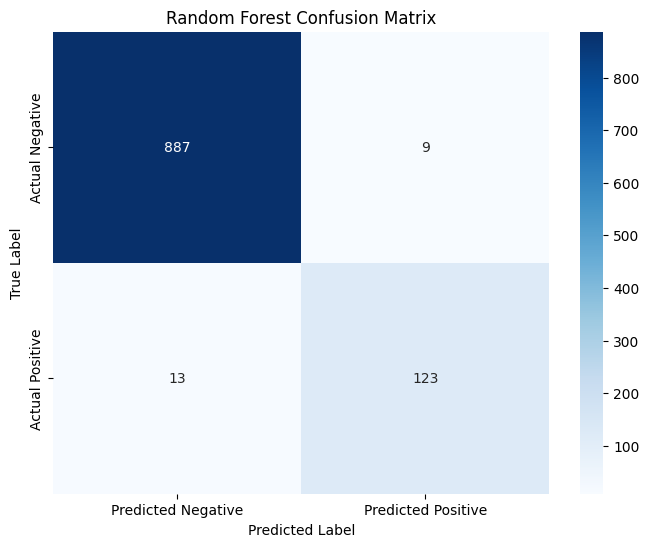

In [84]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Display confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

**Accuracy**

In [85]:
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {rf_acc:.4f}")

Accuracy: 0.9787


**Precision(spam)**

In [86]:
rf_pr = precision_score(y_test, y_pred_rf)
print(f"Precision: {rf_pr:.4f}")

Precision: 0.9318


**Recall(spam)**

In [87]:
rf_rec = recall_score(y_test, y_pred_rf)
print(f"Recall: {rf_rec:.4f}")

Recall: 0.9044


**F1-Score**

In [88]:
rf_f1 = f1_score(y_test, y_pred_rf)
print(f"F1 score: {rf_f1:.4f}")

F1 score: 0.9179
